In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### `Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [2]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [3]:
# code here

df2 = df.stack(level=0, future_stack=True)

df2 = df2.unstack(level=0)

df2 = df2.sort_index(level=0)

df2

avg_package     students    
                    cse ece      cse ece
2019 delhi            1   9        2  10
     mumbai           0   0        0   0
2020 delhi            3  11        4  12
     mumbai           0   0        0   0
2021 delhi            5  13        6  14
     mumbai           0   0        0   0
2022 delhi            7  15        8  16
     mumbai           0   0        0   0

### `Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [4]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [5]:

# Convert wide date columns into rows
confirm_long = confirm.melt(
    id_vars=["Province/State", "Country/Region"],
    var_name="Date",
    value_name="Cases"
)

deaths_long = deaths.melt(
    id_vars=["Province/State", "Country/Region"],
    var_name="Date",
    value_name="Deaths"
)


# Merge both datasets
covid_df = pd.merge(
    confirm_long,
    deaths_long,
    on=["Province/State", "Country/Region", "Date"]
)


# Create MultiIndex
covid_df = covid_df.set_index(["Country/Region", "Province/State"])


# Keep only requested columns
covid_df = covid_df[["Date", "Cases", "Deaths"]]

covid_df.head()

,,Date,Cases,Deaths
Country/Region,Province/State,,,
Afghanistan,NaN,Lat,33.93911,33.93911
Albania,NaN,Lat,41.15330,41.15330
Algeria,NaN,Lat,28.03390,28.03390
Andorra,NaN,Lat,42.50630,42.50630
Angola,NaN,Lat,-11.20270,-11.20270


### `Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [6]:
# code here

# Remove non-date columns
confirm_cases = confirm.drop(columns=["Lat","Long"])
death_cases = deaths.drop(columns=["Lat","Long"])

# Sum across all dates to get total cases per row
confirm_cases["TotalCases"] = confirm_cases.iloc[:,2:].sum(axis=1)
death_cases["TotalDeaths"] = death_cases.iloc[:,2:].sum(axis=1)

# Create country totals
country_confirm = confirm_cases.groupby("Country/Region")["TotalCases"].sum()
country_deaths = death_cases.groupby("Country/Region")["TotalDeaths"].sum()

# Combine both
covid_stats = pd.DataFrame({
    "Confirmed": country_confirm,
    "Deaths": country_deaths
})

# Calculate death percentage
covid_stats["DeathPercent"] = (covid_stats["Deaths"] / covid_stats["Confirmed"]) * 100

# Find country with highest death percent
result = covid_stats.sort_values("DeathPercent", ascending=False).head(1)

print(result)

                Confirmed  Deaths  DeathPercent
Country/Region                                 
Korea, North          234    1404         600.0


### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [7]:
# code here

# Filter rows for India
india = confirm[confirm["Country/Region"] == "India"]

# Remove unnecessary columns
india = india.drop(columns=["Province/State","Country/Region","Lat","Long"])

# Convert date columns into rows
india = india.T

# Rename columns
india.columns = ["Cases"]
india.index.name = "Date"

# Reset index to make Date a column
india = india.reset_index()

# Calculate new cases using shift
india["NewCases"] = india["Cases"] - india["Cases"].shift(1)

# First day's new cases can be equal to cases
india.loc[0, "NewCases"] = india.loc[0, "Cases"]

india.head()

,Date,Cases,NewCases
0,1/22/20,0,0.0
1,1/23/20,0,0.0
2,1/24/20,0,0.0
3,1/25/20,0,0.0
4,1/26/20,0,0.0


### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [8]:
# code here

df = pd.read_csv("https://tinyurl.com/2fe6vz4u")

# keep only needed columns
df = df[["Country", "City/Town", "PM2.5", "PM10"]]

# create MultiIndex
df = df.set_index(["Country", "City/Town"])

df.head()

PM2.5  PM10
Country City/Town             
India   Kanpur       173   319
        Faridabad    172   316
        Gaya         149   275
        Varanasi     146   260
        Patna        144   266

In [9]:
india = df.loc["India"]

most_polluted_india = india["PM10"].idxmax()
print("Most polluted city in India:", most_polluted_india)

Most polluted city in India: Kanpur


In [10]:
least_polluted_india = india["PM10"].idxmin()
print("Least polluted city in India:", least_polluted_india)

Least polluted city in India: Aizawl


In [11]:
china = df.loc["China"]

print("Most polluted city in China:", china["PM10"].idxmax())
print("Least polluted city in China:", china["PM10"].idxmin())

Most polluted city in China: Jinan
Least polluted city in China: Anshun


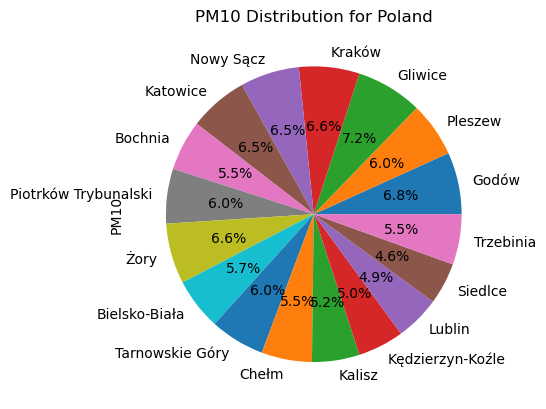

In [12]:
poland = df.loc["Poland"]

poland["PM10"].plot.pie(
    autopct="%1.1f%%",
    title="PM10 Distribution for Poland"
)

plt.show()

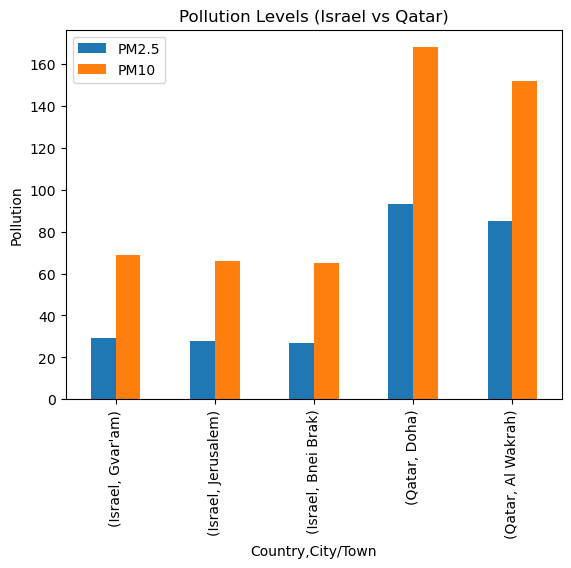

In [13]:
subset = df.loc[["Israel", "Qatar"]][["PM2.5", "PM10"]]

subset.plot.bar(title="Pollution Levels (Israel vs Qatar)")
plt.ylabel("Pollution")
plt.show()

In [14]:
series_data = df.stack()

series_data.head()

Country  City/Town       
India    Kanpur     PM2.5    173
                    PM10     319
         Faridabad  PM2.5    172
                    PM10     316
         Gaya       PM2.5    149
dtype: int64